# Прикладные задачи машинного обучения, DS-поток
## Задание 1

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту `@miptstats_ds24_bot`. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания получат штраф.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.


**Правила оформления теоретических задач:**

* Решения необходимо прислать одним из следующих способов:
  * фотографией в правильной ориентации, где все четко видно, а почерк разборчив,
    * отправив ее как файл боту вместе с ноутбуком *или*
    * вставив ее в ноутбук посредством `Edit -> Insert Image` (<font color="red">фото, вставленные ссылкой, не принимаются</font>);
  * в виде $LaTeX$ в markdown-ячейках.
* Решения не проверяются, если какое-то требование не выполнено. Особенно внимательно все проверьте в случае выбора второго пункта (вставки фото в ноутбук). <font color="red"><b>Неправильно вставленные фотографии могут не передаться при отправке.</b></font> Для проверки попробуйте переместить `ipynb` в другую папку и открыть его там.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

**Баллы за задание:**

* Задача 1 &mdash; 30 балла
* Задача 2 &mdash; 60 баллов
* Задача 3 &mdash; 120 баллов



In [1]:
# Bot check

# HW_ID: ds_ml2_1
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [2]:
# настройка среды в Google Colab
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !pip install swig
    !wget -q https://www.dropbox.com/s/j9ippev95ui05hf/setup_colab.sh?dl=0 -O- | bash
    !pip install 'gymnasium[all]'
    !touch .setup_complete

# Этот код создает виртуальный дисплей, чтобы отображать там игру.
# Ничего не изменится, если на вашей машине есть монитор.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

bash: ../xvfb: No such file or directory


In [3]:
import gymnasium as gym

import numpy as np
np.float_ = np.float64
import seaborn as sns
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import imageio
import typing as tp
from tqdm.notebook import tqdm
from collections import defaultdict

import IPython
from IPython.display import clear_output

sns.set(font_scale=1.2, palette='Set2')
sns.set_style(style='darkgrid')

device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

---
### Задача 1. Уравнения Беллмана

Докажите уравнения Беллмана для выражения $V_\pi(s)$ и $Q_\pi(s, a)$ через их значения на следующих шагах.
1. $\displaystyle V_\pi(s) = \mathsf{E}R(s, a) + \gamma \sum_{a \in \mathcal{A}, s' \in \mathcal{S}} \pi(a | s) P(s' | s, a) V_\pi (s')$;
2. $\displaystyle Q_\pi(s, a) = \mathsf{E}R(s, a) + \gamma \sum_{a' \in \mathcal{A}, s' \in \mathcal{S}} P(s' | s, a) \pi(a' | s') Q_\pi(s', a')$.

$\square$

**СМ PDF**

$\blacksquare$

---
### Задача 2. Теорема об оптимальной стратегии для конечного горизонта

Рассмотрим среду, в которой любая игра состоит ровно из $T$ действий агента и после этого заканчивается. Считайте, что $\mathcal{S}$ и $\mathcal{A}$ конечны.

Пусть
* $V_{opt}(s) = \max\limits_{\pi}V_{\pi}(s)$;
* $Q_{opt}(s, a) = \max\limits_{\pi} Q_{\pi}(s, a)$.

Рассмотрим стратегию
$$\pi^*(a|s) =
 \begin{cases}
   1 &\text{если $a = \arg\max \; Q_{opt}(s, a)$}\\
   0 &\text{иначе}
 \end{cases}.$$

 Доказать, что
 1. Стратегия $\pi^*$ является оптимальной, то есть $\forall \pi: \; \pi^* \geq \pi$;
 2. $\forall s \; V_{\pi^*}(s) = V_{opt}(s)$;
 3. $\forall s \; Q_{\pi^*}(s, a) = V_{opt}(s, a)$.

$\square$

**СМ PDF**

$\blacksquare$

---
### Задача 3. Приближенный кросс-энтропийный метод

В этом ноутбуке вам предлагается реализовать приближенный кросс-энтропийный метод для среды с непрерывным пространством состояний.

Рассмотрим среду [`Acrobot-v1`](https://gymnasium.farama.org/environments/classic_control/acrobot/), которая включает в себя два звена и два шарнира, в которых происходит движение. Первоначально звенья свешиваются вниз, и цель состоит в том, чтобы поднять конец нижнего звена на заданную высоту.

Обучение с подкреплением позволяет не задумываться о том, какие действия существуют в заданной среде и о содержимом вектора состояния.

Размер вектора состояния: 6
Количество возможных действий в среде: 3
Визуализация среды:


/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-pa

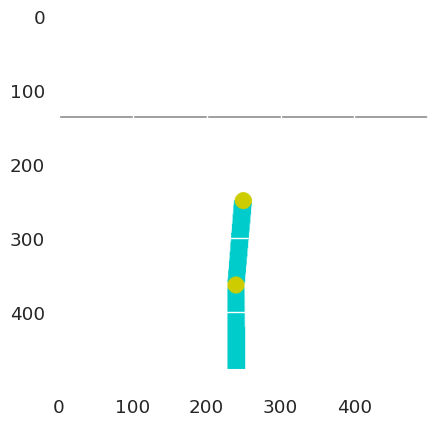

In [4]:
env = gym.make("Acrobot-v1", render_mode="rgb_array")
# устанавливаем максимальное количество итераций в среде (по умолчанию 500)
env._max_episode_steps = 10000

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

print(f"Размер вектора состояния: {state_dim}")
print(f"Количество возможных действий в среде: {n_actions}")

print("Визуализация среды:")
plt.imshow(env.render())
plt.show()

1. Реализуйте нейросетевого агента из нескольких полносвязных слоев, который будет принимать состояние и предсказывать действие в виде логитов.

*Замечание:*
* не ставьте слишком много нейронов в скрытых слоях;
* экспериментируйте в функцией активации, например, можно попробовать `nn.Tanh`.


In [5]:
class Agent(nn.Module):
    def __init__(self):
        super(Agent, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(6, 16),
            nn.Tanh(),
            nn.Linear(16, 3)
        )

    def forward(self, x):
        return self.net(x)

In [6]:
agent = Agent().to(device)

2. Напишите функции, необходимые для генерации сессий.

А именно, функцию, которая по состоянию будет возвращать вероятности действий при игре стратегией агента, и функцию, семплирующая итоговое действие.

In [7]:
def action_probabilities(agent, s: tp.List[float]):
    """
    Функция, возвращающая вероятности действий агента из состояния s.
    :param agent: нейросетевой агент
    :param s: состояние среды

    :return: вероятности действий из состояния s
    """

    s_tensor = torch.tensor(s).to(device)
    action_logits = agent(s_tensor)
    return torch.softmax(action_logits, dim=-1)

In [8]:
def sample_action(probs) -> int:
    """
    Функция, семплирующая действие с заданной вероятностью.
    :param probs: вероятности действий

    :return: действие
    """

    return torch.distributions.Categorical(probs).sample().item()

Функция генерации игровых сессии агента:

In [9]:
def generate_session(agent, t_max: int=1000) -> tp.Tuple[tp.List[float],
                                                         tp.List[float], int]:
    """
    Играет сессию используя нейросетевого агента.
    :param agent: нейросетевой агент
    :param t_max: максимальное количество шагов, после достижения которого
        сессия прерывается

    :return: list состояний
    :return: list действий
    :return: суммарную награду за сессию
    """

    states, actions = [], []
    total_reward = 0
    agent.train(False)
    s, info = env.reset()

    for t in range(t_max):

        # находим вероятности действий
        probs = action_probabilities(agent, s)

        # семплируем действие
        a = sample_action(probs)

        # совершаем действие в среде, переходим в следующее состояние
        new_s, r, done, truncated, info = env.step(a)

        # записываем результаты шага
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if done:
            break
    return states, actions, total_reward

In [10]:
states, actions, reward = generate_session(agent, t_max=1000)
assert type(states) == type(actions) == list
assert len(states) == len(actions)

3. Напишите функцию, которая будет возвращать действия и состояния из лучших сессий.

*Пример:*

Допустим мы сыграли $5$ сессий. Каждая эта сессия состояла из:
* множества состояний $S_i = (s_{i1}, \dots, s_{in_{i}}), i\in \{1, \dots, 5\}$, где ${n_i}$ - число шагов в данной сессии;
* множества действий $A_i = (a_{i1}, \dots, a_{in_{i}}), i\in \{ 1, \dots, 5\}$, причем каждому действию соответствует состояние, в которое среда перешла после совершения действия;
* суммарной награды за сессию $R_i, i\in \{1, \dots, 5\}$.

Допустим нам нужно выбрать хотя бы $40\%$ лучших сессий (отсеять  не более `percentile`$=60\%$ худших сессий). Соответственно мы выбираем такие $J \subset \{1, \dots, 5\}, |J| \geq 2$, что $\forall i \in \{1, \dots, 5\}: i \notin J, \forall j \in J(R_{j} > R_{i}) $. Допустим $J = \{j_1, j_2\}$.

Соответственно нам нужно вернуть лист состояний лучших сессий $[s_{j_11}, \dots, s_{j_1n_{j_1}}, s_{j_21}, \dots, s_{j_2n_{j_2}}]$ и лист действий лучших сессий $[a_{j_11}, \dots, a_{j_1n_{j_1}}, a_{j_21}, \dots, a_{j_2n_{j_2}}]$.

In [11]:
def select_elites(states_batch: tp.List[tp.List[float]],
                  actions_batch: tp.List[tp.List[float]],
                  rewards_batch: tp.List[float],
                  percentile: float) -> tp.Tuple[tp.List[float],
                                                 tp.List[float]]:
    """
    Возвращает действия и состояния из лучших сессий.
    :param states_batch: List[List[float]] состояния сыгранных сессий
    :param actions_batch: List[List[float]] действия сыгранных сессий
    :param rewards_batch: List[float] награды сыгранных сессий
    :param percentile: процент неучитываемых сессий

    :return: tp.List[float] состояния лучших сессий
    :return: tp.List[float] действия лучших сессий, которые
        принимались в состояниях elite_states
    """

    threshold = np.percentile(rewards_batch, percentile)
    elite_indices = np.where(rewards_batch >= threshold)[0]
    
    elite_states = []
    elite_actions = []
    
    for idx in elite_indices:
        elite_states.extend(states_batch[idx])
        elite_actions.extend(actions_batch[idx])
    
    elite_states = np.array(elite_states, dtype=np.float32)
    elite_actions = np.array(elite_actions, dtype=np.int64)
    return torch.tensor(elite_states), torch.tensor(elite_actions)

In [12]:
def show_progress(rewards: tp.List[float],
                  history: tp.Dict[str, tp.List[float]]):
    """
    Функция визуализации прогресса обучения модели.

    :param rewards: награды сыгранных агентом сессий
    :param history: история средних наград и порогов
    """

    clear_output(True)
    print("Средняя награда: {:.3f}, Порог выбора лучших сессий: {:.3f}".format(
        history["mean_reward"][-1],
        history["threshold"][-1])
    )

    plt.figure(figsize=[16, 6])
    plt.subplot(1, 2, 1)
    plt.title("История наград при обучении")
    plt.plot(history["mean_reward"], label='Средняя награда', lw=2)
    plt.plot(history["threshold"], label='Порог выбора лучших сессий', lw=2)
    plt.xlabel("Эпоха")
    plt.ylabel("Средняя награда")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.title("Распределение наград за прошедшую эпоху")
    plt.hist(rewards, range=[np.min(rewards), np.max(rewards)])
    plt.vlines(history["threshold"][-1], [0], [100], label="Процентиль",
               color='red')
    plt.xlabel("Награда")
    plt.ylabel("Число сессий")
    plt.legend()
    plt.grid()

    plt.show()

4. Обучите агента на состояниях и действиях из лучших сессий. Фактически, агент решает задачу классификации состояний по действиям.

Ранее в курсе задача классификации уже решалась с помощью нейронных сетей, нужно повторить примерно те же действия, но уже в контексте RL. Можете посмотреть, как эта функция применяется ниже.

In [13]:
def fit_agent(agent, criterion, optimizer, elite_states, elite_actions, batch_size=32):
    """
    Функция для обучения агента на лучших сессиях.
    Совершает один проход по данным.

    :param model: обучаемый агент
    :param criterion: функция потерь
    :param optimizer: метод оптимизации
    :param elite_states: состояния лучших сессий
    :param elite_actions: действия лучших сессий, которые
        принимались в состояниях elite_states
    :param batch_size: размер батча
    """    
    dataset = TensorDataset(elite_states, elite_actions)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=8)

    for states_batch, actions_batch in loader:
        optimizer.zero_grad()

        states_batch = states_batch.to(device)
        actions_batch = actions_batch.to(device)

        logits = agent(states_batch)
        loss = criterion(logits, actions_batch)

        loss.backward()
        optimizer.step()

Задача считается решенной, когда средняя награда на сгенерированных сессиях становится больше $-85$.

*Замечание:* чтобы добиться требуемой точности можно поэкспериментировать:
* с архитектурой нейронной сети;
* с процентом лучших сессий;
* со способом оптимизации и величиной градиентного шага;
* с максимальным количеством итераций.

Средняя награда: -84.190, Порог выбора лучших сессий: -73.700


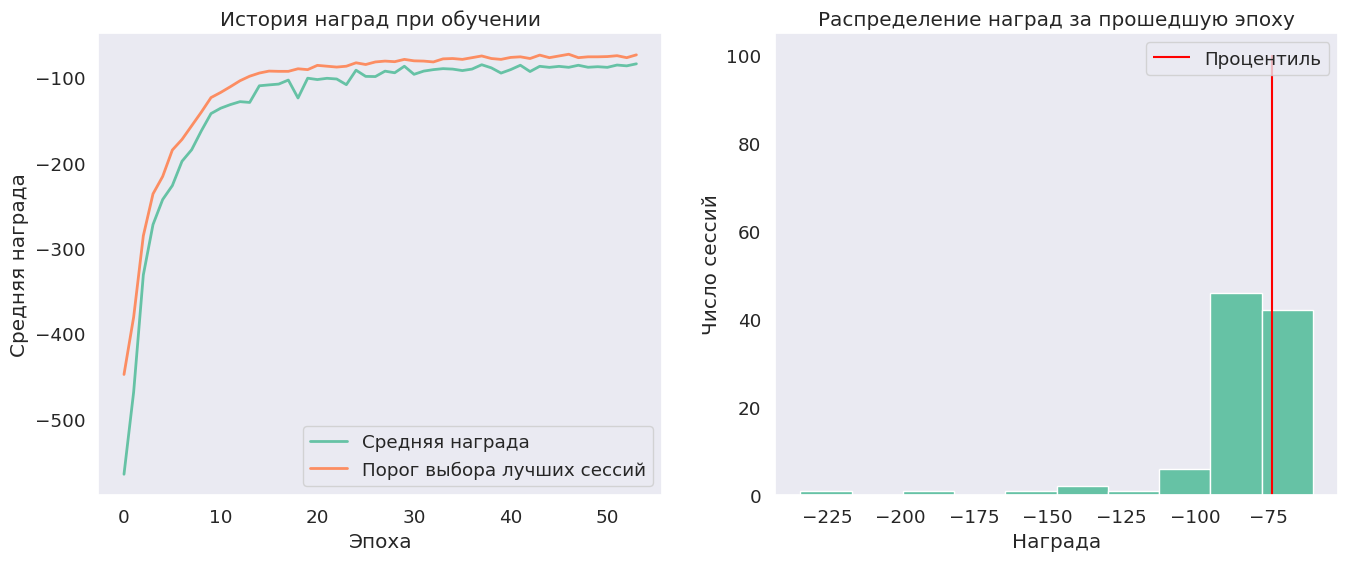

Вы преодолели порог!


In [14]:
# порог, прохождение которого означает успешное решение задачи
reward_threshold = -85

def train_agent(
    n_sessions=100,  # количество генерируемых сессий на каждой итерации
    percentile=70,   # процент неучитываемых сессий
    n_epochs=100,    # число итераций алгоритма
):
    '''
    Функция, реализующая общий пайплайн обучения модели
    Несколько раз генерирует некоторое количество сессий, берет из них наилучшие
    и обновляет агента

    :param n_sessions: количество генерируемых на одной итерации сессий
    :param percentile: процент неучитываемых сессий
    :param n_epochs: количество итераций обновления модели
    '''
    agent = Agent().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(agent.parameters(), lr=0.001)

    history = defaultdict(list)

    for _ in tqdm(range(n_epochs)):
        # Генерируем новые сессии
        sessions = [generate_session(agent) for _ in tqdm(range(n_sessions), desc="Generating sessions")]
        states_batch, actions_batch, rewards_batch = map(lambda l: np.array(l, dtype=object), zip(*sessions))

        # Выбираем сессии с лучшей суммарной наградой
        elite_states, elite_actions = select_elites(states_batch, actions_batch,
                                                    rewards_batch, percentile)

        # Обучаем агента на лучших сессиях
        fit_agent(agent, criterion, optimizer, elite_states, elite_actions, batch_size=32)

        # Визуализируем прогресс обучения:
        history["mean_reward"].append(np.mean(rewards_batch))
        history["threshold"].append(np.percentile(rewards_batch, percentile))

        show_progress(rewards_batch, history)

        if np.mean(rewards_batch) > reward_threshold:
            print("Вы преодолели порог!")
            break

    torch.save(agent.state_dict(), "agent_weights.pt")
    return agent

agent = train_agent(n_sessions=100, percentile=70)


Визуализация игры обученного агента:

In [15]:
def show_agent(agent, t_max=1000, title='', gif_path=None, show=True):
    fig = plt.figure(figsize=(6, 5))
    clear_output(wait=True)
    frames = []

    s, info = env.reset()
    step_number = 0
    for t in range(t_max):
        step_number += 1
        plt.gca().clear()
        plt.grid(False)
        plt.axis('off')

        # вероятности действий
        probs = action_probabilities(agent, s)

        # семплируем действие
        a = sample_action(probs)

        # делаем шаг
        new_s, r, done, truncated, info = env.step(a)
        s = new_s

        # визуализируем
        plt.title(title)
        plt.imshow(env.render())

        # конвертируем fig в np.array
        canvas = fig.canvas
        canvas.draw()
        width, height = canvas.get_width_height()
        image_array = np.frombuffer(canvas.renderer.buffer_rgba(), dtype=np.uint8)
        image_array = image_array.reshape(height, width, 4)  # RGBA
        image_array = image_array[:, :, :3]  # RGB
        frames.append(image_array)

        clear_output(wait=True)
        if show:
            display(plt.gcf())

        if done:
            break

    clear_output(wait=True)
    print(f"{step_number} совершенных действий")
    if not show:
        plt.close()

    # сохраняем gif
    if gif_path is not None:
        import imageio
        imageio.mimsave(gif_path, frames, duration=1/12)

    return frames

84 совершенных действий


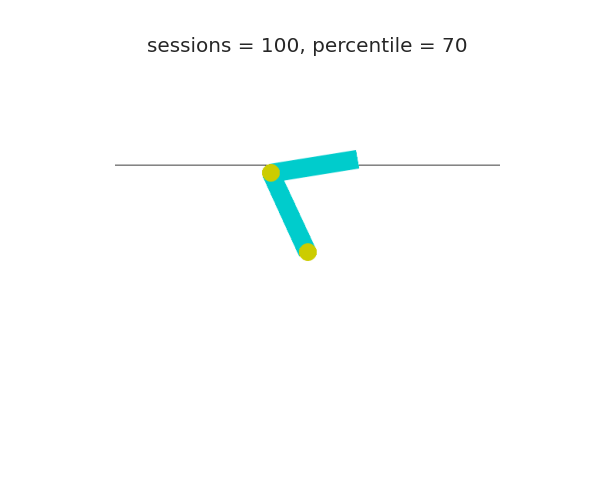

In [16]:
show_agent(agent, title='sessions = 100, percentile = 70', gif_path='agent_100_70.gif', show=False)
display(IPython.display.Image('agent_100_70.gif'))

5. Посмотрите, как графики обучения алгоритма меняются в зависимости от `n_sessions` и/или `percentile`.

Посмотрим на влияние параметра `n_sessions`.

In [17]:
def ablation_n_sessions(agent_class, n_sessions_list, percentile=70, n_epochs=100):
    """
    Запускает обучение для разных значений n_sessions и рисует прогресс на одном графике.

    :param agent_class: класс агента (например Agent)
    :param n_sessions_list: список чисел сессий для сравнения
    :param percentile: фиксированный percentile для отбора элиты
    :param n_epochs: количество эпох обучения
    """

    plt.figure(figsize=(12, 6))

    for n_sessions in n_sessions_list:
        print(f"Обучение с n_sessions={n_sessions}")
        agent = agent_class().to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(agent.parameters(), lr=0.001)
        history = defaultdict(list)

        for _ in range(n_epochs):
            sessions = [generate_session(agent) for _ in range(n_sessions)]
            states_batch, actions_batch, rewards_batch = map(lambda l: np.array(l, dtype=object), zip(*sessions))
            elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)
            fit_agent(agent, criterion, optimizer, elite_states, elite_actions, batch_size=32)

            # сохраняем прогресс
            history["mean_reward"].append(np.mean(rewards_batch))
            history["threshold"].append(np.percentile(rewards_batch, percentile))

        plt.plot(history["mean_reward"], label=f"n_sessions={n_sessions}", lw=2)

    plt.title("Сравнение прогресса обучения при разных n_sessions")
    plt.xlabel("Эпоха")
    plt.ylabel("Средняя награда")
    plt.legend()
    plt.grid()
    plt.show()

Обучение с n_sessions=25
Обучение с n_sessions=50
Обучение с n_sessions=100
Обучение с n_sessions=150
Обучение с n_sessions=200


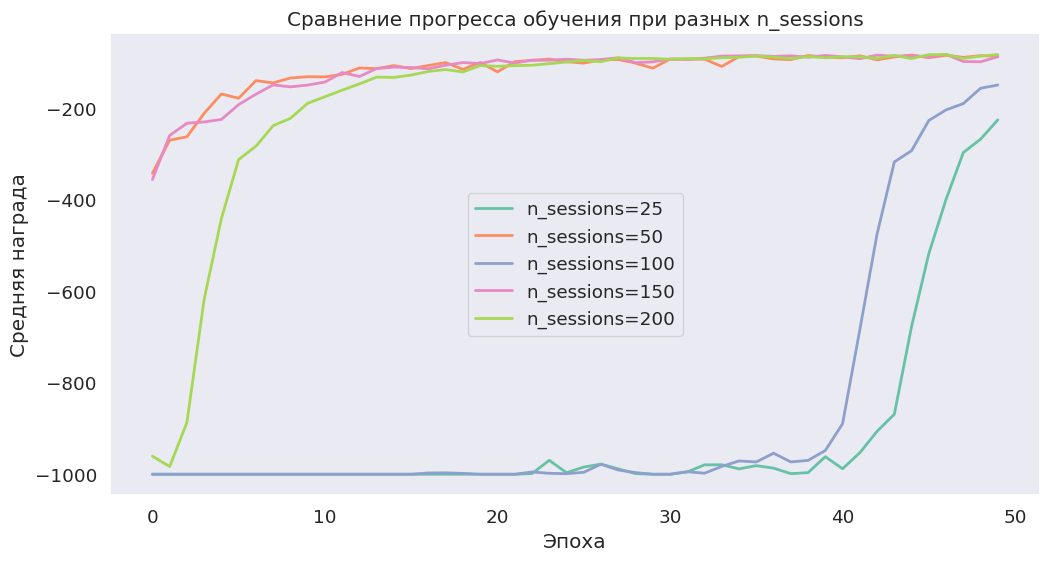

In [18]:
ablation_n_sessions(Agent, n_sessions_list=[25, 50, 100, 150, 200], percentile=70, n_epochs=50)

Посмотрим на влияние параметра `percentile`.

In [19]:
def ablation_percentile(agent_class, n_sessions=100, percentile_list=None, n_epochs=100):
    """
    Запускает обучение для разных значений percentile и рисует прогресс на одном графике.

    :param agent_class: класс агента (например Agent)
    :param n_sessions: фиксированное количество сессий
    :param percentile_list: список percentiles для сравнения
    :param n_epochs: количество эпох обучения
    """
    if percentile_list is None:
        percentile_list = [50, 60, 70, 80, 90]

    plt.figure(figsize=(12, 6))

    for percentile in percentile_list:
        print(f"Обучение с percentile={percentile}")
        agent = agent_class().to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(agent.parameters(), lr=0.001)
        history = defaultdict(list)

        for _ in range(n_epochs):
            sessions = [generate_session(agent) for _ in range(n_sessions)]
            states_batch, actions_batch, rewards_batch = map(lambda l: np.array(l, dtype=object), zip(*sessions))
            elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)
            fit_agent(agent, criterion, optimizer, elite_states, elite_actions, batch_size=32)

            history["mean_reward"].append(np.mean(rewards_batch))
            history["threshold"].append(np.percentile(rewards_batch, percentile))

        plt.plot(history["mean_reward"], label=f"percentile={percentile}", lw=2)

    plt.title("Сравнение прогресса обучения при разных percentile")
    plt.xlabel("Эпоха")
    plt.ylabel("Средняя награда")
    plt.legend()
    plt.grid()
    plt.show()


Обучение с percentile=50
Обучение с percentile=60
Обучение с percentile=70
Обучение с percentile=80
Обучение с percentile=90


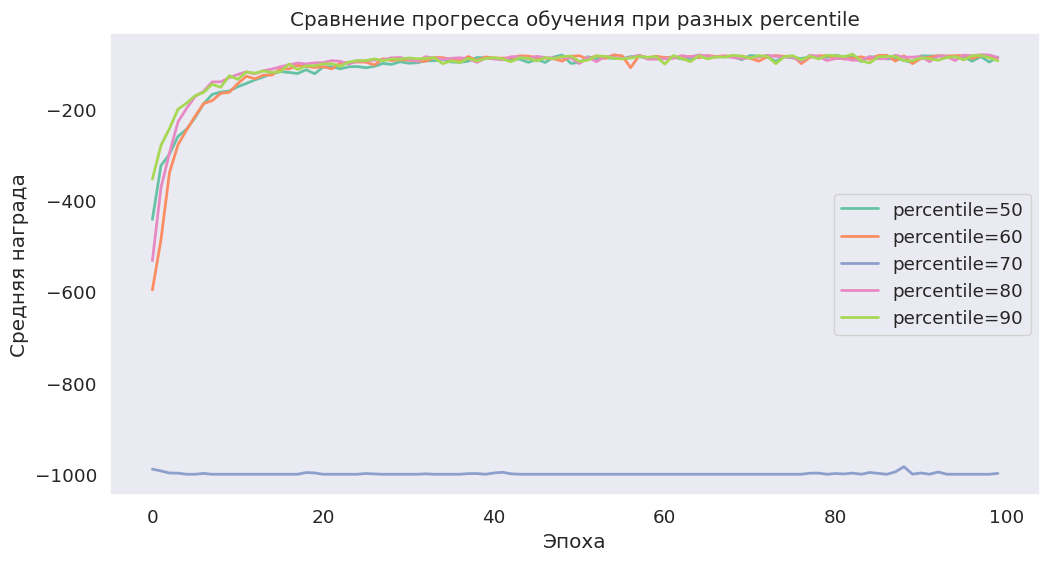

In [20]:
ablation_percentile(Agent, n_sessions=100, percentile_list=[50, 60, 70, 80, 90], n_epochs=100)